TP3: Etape1

In [10]:
import pandas as pd
import numpy as np

df2 = pd.read_csv("transactions.csv")
df_clean = df2.copy()

# 1) Retirer les lignes sans client (indispensable TP2)
df_clean = df_clean.dropna(subset=["customer_id"])

# 2) Retirer prix négatifs / nuls
df_clean = df_clean[df_clean["unit_price"] > 0]

# 3) Retirer quantités négatives / nulles (retours, annulations)
df_clean = df_clean[df_clean["quantity"] > 0]

# 4) Retirer dates invalides
df_clean = df_clean.dropna(subset=["invoice_date"])

# 5) Retirer doublons exacts
df_clean = df_clean.drop_duplicates()

# 6) Retirer doublons métier (même facture, client, produit)
df_clean = df_clean.drop_duplicates(subset=["invoice_id", "customer_id", "product_code"])

FileNotFoundError: [Errno 2] No such file or directory: 'transactions.csv'

In [ ]:
#Période d'observation (features) : les 12 premiers mois du dataset
df_clean["invoice_date"] = pd.to_datetime(df_clean["invoice_date"])
obs_start = df_clean["invoice_date"].min()

In [ ]:
#Période cible (target) : les 12 mois suivants
obs_end = obs_start + pd.DateOffset(years=1)
target_start = obs_end
target_end = target_start + pd.DateOffset(years=1)
print("Période d'observation:", obs_start.date(), "to", obs_end.date())
print("Période cible:", target_start.date(), "to", target_end.date())

Période d'observation: 2007-07-06 to 2008-07-06
Période cible: 2008-07-06 to 2009-07-06


In [ ]:
df_clean["line_total"] = df_clean["quantity"] * df_clean["unit_price"]

In [ ]:
df_obs = df_clean[(df_clean["invoice_date"] >= start_date) &
            (df_clean["invoice_date"] < obs_end)]

df_target = df_clean[(df_clean["invoice_date"] >= obs_end) &
               (df_clean["invoice_date"] < target_end)]

print("Transactions observation :", len(df_obs))
print("Transactions target :", len(df_target))

Transactions observation : 2084
Transactions target : 28500


In [ ]:
# Calculez la CLV historique pour chaque client sur la période cible. C'est ce que le modèle devra apprendre à prédire
# depuis les features de la période d'observation.
clv_target = df_clean[
    (df_clean["invoice_date"] >= target_start) &
    (df_clean["invoice_date"] < target_end)
].groupby("customer_id")["line_total"].sum().reset_index().rename(columns={"line_total": "clv_target"})

print("CLV cible (extrait):")
print(clv_target.head())

CLV cible (extrait):
   customer_id  clv_target
0      21467.0      214.20
1      21470.0       72.00
2      21584.0      130.80
3      21664.0       20.80
4      21712.0       20.28


Étape 2 : Feature engineering

In [ ]:
#Construisez au moins 15 features depuis la période d'observation :
# Features RFM (base) :
# Récence, fréquence, montant total, panier moyen 

In [ ]:
#Base RFM (4 features)
rfm_obs = df_obs.groupby("customer_id").agg(
    last_purchase=("invoice_date", "max"),
    frequency=("invoice_id", "nunique"),
    monetary=("line_total", "sum")
)

snapshot_obs = df_obs["invoice_date"].max() + pd.Timedelta(days=1)

rfm_obs["recency"] = (snapshot_obs - rfm_obs["last_purchase"]).dt.days
rfm_obs["avg_basket"] = rfm_obs["monetary"] / rfm_obs["frequency"]

rfm_obs = rfm_obs.drop(columns=["last_purchase"])

rfm_obs.head()

,frequency,monetary,recency,avg_basket
customer_id,,,,
23236.0,1,30.00,52,30.00
23241.0,1,23.55,69,23.55
23259.0,1,15.25,46,15.25
23281.0,1,17.85,20,17.85
23293.0,1,15.00,227,15.00


In [ ]:
#1 feature supplémentaire : nombre de produits distincts achetés
rfm_obs["n_distinct_products"] = (
    df_obs.groupby("customer_id")["product_code"].nunique()
)

In [ ]:
#recherche d'une feature de régularité d'achat : écart-type des inter-achats
def interpurchase_std(x):
    dates = x.sort_values()
    diffs = dates.diff().dt.days.dropna()
    return diffs.std()

rfm_obs["std_interpurchase"] = (
    df_obs.groupby("customer_id")["invoice_date"]
    .apply(interpurchase_std)
)

In [ ]:
#recherche d'une feature de régularité d'achat : nombre de mois actifs
df_obs["year_month"] = df_obs["invoice_date"].dt.to_period("M")

rfm_obs["n_active_months"] = (
    df_obs.groupby("customer_id")["year_month"].nunique()
)

In [ ]:
#feature de tenure : nombre de jours depuis le premier achat
first_purchase_obs = df_obs.groupby("customer_id")["invoice_date"].min()

rfm_obs["tenure_days"] = (snapshot_obs - first_purchase_obs).dt.days

In [ ]:
#feature de saisonnalité : mois du premier achat
rfm_obs["first_purchase_month"] = first_purchase_obs.dt.month

In [ ]:
#feature de tendance de dépense : pente de la régression linéaire du montant dépensé par mois
from sklearn.linear_model import LinearRegression

def spending_trend(customer_df):
    monthly = (
        customer_df
        .set_index("invoice_date")
        .resample("ME")["line_total"]
        .sum()
        .reset_index()
    )
    
    if len(monthly) < 2:
        return 0
    
    X = np.arange(len(monthly)).reshape(-1,1)
    y = monthly["line_total"].values
    
    model = LinearRegression()
    model.fit(X,y)
    return model.coef_[0]

rfm_obs["spending_trend"] = (
    df_obs.groupby("customer_id")
    .apply(spending_trend)
)

In [ ]:
#feature de saisonnalité : ratio de transactions pendant les mois de pic (ex: novembre, décembre)
peak_months = [11, 12]  # à adapter si besoin

df_obs["is_peak"] = df_obs["invoice_date"].dt.month.isin(peak_months)

rfm_obs["peak_ratio"] = (
    df_obs.groupby("customer_id")["is_peak"].mean()
)

In [ ]:
#feature de complexité du panier : nombre moyen d'items par commande
avg_items = (
    df_obs.groupby(["customer_id","invoice_id"])
    .size()
    .groupby("customer_id")
    .mean()
)

rfm_obs["avg_items_per_order"] = avg_items

In [ ]:
#feature de localisation : pays le plus fréquent d'achat
rfm_obs["country"] = (
    df_obs.groupby("customer_id")["country"]
    .agg(lambda x: x.mode().iloc[0])
)

In [9]:
#feature de fréquence d'achat par mois actif : nombre de commandes divisé par nombre de mois actifs
rfm_obs["freq_per_active_month"] = (
    rfm_obs["frequency"] / rfm_obs["n_active_months"]
)

NameError: name 'rfm_obs' is not defined

In [8]:
#feature de dépense par jour de tenure : montant total dépensé divisé par nombre de jours depuis le premier achat
rfm_obs["spend_per_day"] = (
    rfm_obs["monetary"] / rfm_obs["tenure_days"]
)

NameError: name 'rfm_obs' is not defined

In [7]:
#Merge features + target
model_df = rfm_obs.merge(clv_target, left_index=True, right_index=True)

model_df = model_df.fillna(0)

model_df.head()

NameError: name 'rfm_obs' is not defined

Étape 3 : Modélisation et évaluation


In [6]:
# Vérification du dataset final
print("Shape model_df:", model_df.shape)
display(model_df.head())
print("Colonnes:", list(model_df.columns))

# Détection automatique de la target
if "CLV_12m" in model_df.columns:
    target_col = "CLV_12m"
elif "clv_target" in model_df.columns:
    target_col = "clv_target"
else:
    raise ValueError("Aucune target trouvée : attendu 'CLV_12m' ou 'clv_target'.")

print("Target utilisée:", target_col)

NameError: name 'model_df' is not defined

In [ ]:
model_df_sorted = model_df.sort_values("recency")

split_index = int(len(model_df_sorted) * 0.8)

train = model_df_sorted.iloc[:split_index]
test = model_df_sorted.iloc[split_index:]

print("Train:", len(train))
print("Test:", len(test))

Train: 511
Test: 128


In [ ]:
X_train = train.drop(columns=["CLV_12m"])
y_train = train["CLV_12m"]

X_test = test.drop(columns=["CLV_12m"])
y_test = test["CLV_12m"]

X_train.head()

,frequency,monetary,recency,avg_basket
customer_id,,,,
62270.0,2,1712.55,1,856.275
54425.0,1,34.80,1,34.800
26720.0,1,46.28,1,46.280
48626.0,1,19.50,1,19.500
26996.0,1,15.30,1,15.300


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)

pred_lr = linreg.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
mae_lr = mean_absolute_error(y_test, pred_lr)
r2_lr = r2_score(y_test, pred_lr)

print("Linear Regression")
print("RMSE:", rmse_lr)
print("MAE:", mae_lr)
print("R2:", r2_lr)

Linear Regression
RMSE: 53.81277854414309
MAE: 36.582020024071966
R2: -0.6000514981856295


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
mae_rf = mean_absolute_error(y_test, pred_rf)
r2_rf = r2_score(y_test, pred_rf)

print("Random Forest")
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)
print("R2:", r2_rf)

Random Forest
RMSE: 131.21914667557903
MAE: 50.25540260416666
R2: -8.51387729034772


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "RMSE": [rmse_lr, rmse_rf],
    "MAE": [mae_lr, mae_rf],
    "R2": [r2_lr, r2_rf]
})

results.sort_values("RMSE")

,Model,RMSE,MAE,R2
0,Linear Regression,53.812779,36.582020,-0.600051
1,Random Forest,131.219147,50.255403,-8.513877


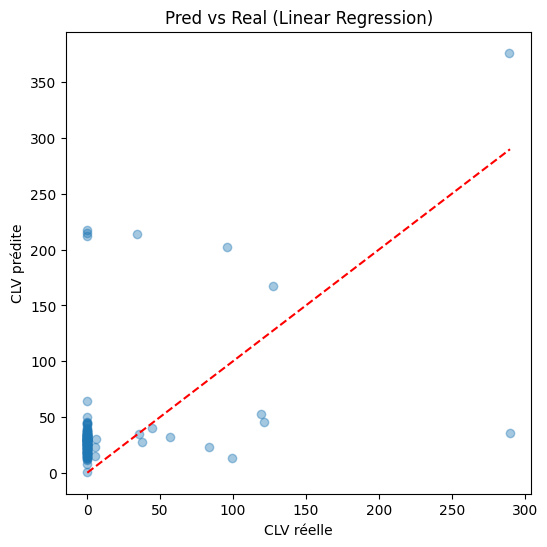

In [ ]:
import matplotlib.pyplot as plt

best_pred = pred_rf if rmse_rf < rmse_lr else pred_lr
best_name = "Random Forest" if rmse_rf < rmse_lr else "Linear Regression"

plt.figure(figsize=(6,6))
plt.scatter(y_test, best_pred, alpha=0.4)
plt.xlabel("CLV réelle")
plt.ylabel("CLV prédite")
plt.title(f"Pred vs Real ({best_name})")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.show()

In [ ]:
print("Shape model_df:", model_df.shape)
print(results)  # si tu as déjà le tableau des modèles

NameError: name 'model_df' is not defined